# Stock Price Prediction with LSTM

The goal is to predict the closing price of the Apple stock with an LSTM network, a recurrent neural network for sequences. The data has the daily prices and volumes of the Apple stock from 23 April 2008 to 31 December 2021 (3,449 trading days, `apple_stock.csv`, downloaded with the `yfinance` package as in the reference; the prices are adjusted for the share splits of 2014 and 2020).

Reference solution: [Stock Price Prediction with LSTM](https://amanxai.com/2022/01/03/stock-price-prediction-with-lstm/) (Aman Kharwal). The reference predicts the closing price of a day from the opening price, the highest price, the lowest price and the volume of the same day, splits the days randomly into a training and a test set, and trains a two-layer LSTM with a batch size of 1 for 30 epochs. It prints the loss on the training data and one hand-typed prediction, and gives no error on the test data.

This notebook shows why that setting does not forecast anything, and builds a real forecast of the next day's price from the prices of the previous 60 days, tested on the last period of the data that the model has never seen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Deep Learning/stock_price_prediction_lstm')
tf.keras.utils.set_random_seed(42)

I0000 00:00:1790342662.824029   73848 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790342662.909905   73848 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790342665.445684   73848 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Data Loading

In [2]:
data = pd.read_csv("apple_stock.csv", parse_dates=["Date"])
print(data.shape, "| null values:", data.isnull().sum().sum())
data.head(3)

(3449, 7) | null values: 0


,Date,Open,High,Low,Close,Adj Close,Volume
0,2008-04-23,5.858929,5.887143,5.752857,5.817500,4.871980,1504190800
1,2008-04-24,5.905000,6.070714,5.685357,6.033571,5.052933,1696066400
2,2008-04-25,6.096429,6.110714,5.943571,6.061786,5.076561,992474000


## Exploratory Data Analysis

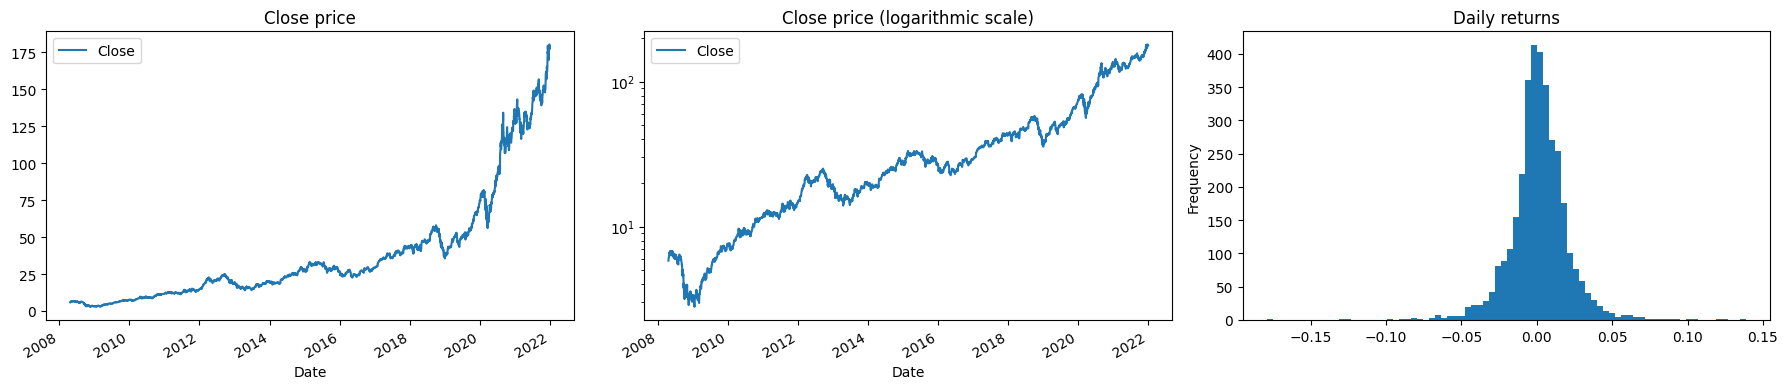

{'Open': 0.9998, 'High': 0.9999, 'Low': 0.9999, 'Close': 1.0, 'Volume': -0.4959}
close price from 5.82 to 177.57 | daily return standard deviation: 1.96 %


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
data.plot(x="Date", y="Close", ax=axes[0], title="Close price")
data.plot(x="Date", y="Close", ax=axes[1], logy=True, title="Close price (logarithmic scale)")
data["Close"].pct_change().plot(kind="hist", bins=80, ax=axes[2], title="Daily returns")
plt.tight_layout(); plt.show()

print(data[["Open", "High", "Low", "Close", "Volume"]].corr()["Close"].round(4).to_dict())
print("close price from", round(data["Close"].iloc[0], 2), "to", round(data["Close"].iloc[-1], 2), "| daily return standard deviation:", round(data["Close"].pct_change().std() * 100, 2), "%")

The close price grows from 5.82 to 177.57 dollars over the 14 years, a factor of 30, so the prices of the last years are far outside the range of the first years. The logarithmic scale shows a more regular growth. The open, the high and the low of a day are almost perfectly correlated with its close (0.9998 to 0.9999), and the volume negatively (-0.50), because the volume figures are larger in the early years when the price was low. The daily return is close to a bell shape with a standard deviation of 1.96% and some large moves in the tails.

## Reference Check

The reference features are the open, the high and the low of the day and the volume. The high and the low of a day are known only when the day is over, at the same time as the close, so the model does not predict the close: it computes it from numbers that already contain it. A plain linear regression on the same features, with the random split of the reference (80/20, `random_state=42`), shows that no neural network is needed.

In [4]:
same_day = ["Open", "High", "Low", "Volume"]
x_train, x_test, y_train, y_test = train_test_split(data[same_day], data["Close"], test_size=0.2, random_state=42)
prediction = LinearRegression().fit(x_train, y_train).predict(x_test)

print("linear regression on the same-day open, high, low and volume (random split):")
print("R2:", round(r2_score(y_test, prediction), 5), "| MAE:", round(mean_absolute_error(y_test, prediction), 3), "dollars | MAPE:", round(np.mean(np.abs(y_test - prediction) / y_test) * 100, 2), "%")

linear regression on the same-day open, high, low and volume (random split):
R2: 0.9999 | MAE: 0.181 dollars | MAPE: 0.49 %


The linear regression reaches an R2 of 0.9999 and a mean error of 18 cents (0.49% of the price), so the reference task is not difficult and not a forecast: the close of a day is computed from the high and the low of the same day, which are only known when the day is over. The random split makes it worse, because the test days lie between training days, so the model sees the prices of the days before and after every test day. Three other points of the reference explain why its network is hard to train: its LSTM receives the four features as a sequence of four time steps (`input_shape=(4, 1)`), although they are not ordered in time; the features are not scaled (the volume goes up to 2.6 billion and the prices are below 200); and the batch size of 1 makes the training loss jump between 2 and 9 from one epoch to the next. The reference does not compute an error on test data, so none of this is visible in its results.

## Feature Engineering

To forecast, the model may only use what is known before the day to predict. The input is a window of the 60 previous days and the target is the next day. Two versions of the input are built:

- **Prices:** the close prices, scaled to the range 0 to 1 with a `MinMaxScaler` fitted on the training days only.
- **Returns:** the daily percentage changes of the close price, divided by their standard deviation in the training days. A return does not depend on the level of the price, so the model can be used when the price is much higher than in the training years.

The days are split in time order: the first 70% for training, the next 15% for validation (used to stop the training) and the last 15% (from 12 December 2019, 518 days) for the test. The test period contains the strong rise of the Apple stock in 2020 and 2021, which is above the prices of all the training years (the maximum of the training years is 44 dollars, and the lowest price of the test period is 56 dollars).

In [5]:
close = data["Close"].values
returns = np.diff(np.log(close))
n = len(close)
train_end, val_end = int(n * 0.70), int(n * 0.85)

def windows(series, size=60):
    return np.array([series[i:i + size] for i in range(len(series) - size)]), series[size:]

# prices, scaled with the training days only
price_scaler = MinMaxScaler().fit(close[:train_end].reshape(-1, 1))
scaled = price_scaler.transform(close.reshape(-1, 1)).ravel()
x_price, y_price = windows(scaled)

# returns, divided by their training standard deviation; the window i predicts the return of the day i + 61
return_std = returns[:train_end - 1].std()
x_return, y_return = windows(returns / return_std)

# the price window i predicts the price of the day i + 60
day = np.arange(60, n)
day_ret = np.arange(61, n)
train, val, test = day < train_end, (day >= train_end) & (day < val_end), day >= val_end
train_r, val_r, test_r = day_ret < train_end, (day_ret >= train_end) & (day_ret < val_end), day_ret >= val_end
print("training windows:", train.sum(), "| validation:", val.sum(), "| test:", test.sum(), "| test starts on", data["Date"].iloc[val_end].date())

training windows: 2354 | validation: 517 | test: 518 | test starts on 2019-12-12


## Model Training

Both versions use the same network: one LSTM layer with 64 units followed by one output neuron. The training stops when the validation loss has not improved for 10 epochs, and the weights of the best epoch are kept. A return needs two prices, so the first return window predicts the 61st day; the validation and test days are the same for both versions.

In [6]:
def lstm_model():
    model = Sequential([Input(shape=(60, 1)), LSTM(64), Dense(1)])
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

price_model = lstm_model()
price_history = price_model.fit(x_price[train][..., None], y_price[train], validation_data=(x_price[val][..., None], y_price[val]),
                                batch_size=32, epochs=100, callbacks=[early_stop], verbose=0)

return_model = lstm_model()
return_history = return_model.fit(x_return[train_r][..., None], y_return[train_r], validation_data=(x_return[val_r][..., None], y_return[val_r]),
                                  batch_size=32, epochs=100, callbacks=[early_stop], verbose=0)
print("epochs trained: prices", len(price_history.history["loss"]), "| returns", len(return_history.history["loss"]))

I0000 00:00:1790342670.202601   73848 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1790342673.171328   73914 cuda_dnn.cc:461] Loaded cuDNN version 92400


epochs trained: prices 100 | returns 10


The predictions of the two models are converted back into prices for the same days of the test period: the scaled price is scaled back, and the predicted return is applied to the close of the day before (`close * exp(return)`).

In [7]:
test_days = day[test]
actual = close[test_days]
previous = close[test_days - 1]

price_pred = price_scaler.inverse_transform(price_model.predict(x_price[test][..., None], verbose=0)).ravel()

return_factor = np.exp(return_model.predict(x_return[test_r][..., None], verbose=0).ravel() * return_std)
return_pred = previous * return_factor

## Evaluation

In [8]:
mask = np.ones(len(actual), dtype=bool)
comparison = {
    "Last value (yesterday's close)": previous,
    "Mean of the last 5 days": np.array([close[d - 5:d].mean() for d in test_days]),
    "Drift (yesterday + average daily change)": previous + (close[train_end - 1] - close[0]) / (train_end - 1),
    "LSTM on prices (scaled)": price_pred,
    "LSTM on returns": return_pred,
}

def scores(prediction):
    error = actual[mask] - prediction[mask]
    up = np.sign(prediction[mask] - previous[mask])
    return {"MAE": np.mean(np.abs(error)), "RMSE": np.sqrt(np.mean(error ** 2)), "MAPE (%)": np.mean(np.abs(error) / actual[mask]) * 100, "mean error": error.mean(),
            "direction correct (%)": (up == np.sign(actual[mask] - previous[mask])).mean() * 100 if (up != 0).any() else np.nan}

pd.DataFrame({name: scores(p) for name, p in comparison.items()}).T.round(2)

,MAE,RMSE,MAPE (%),mean error,direction correct (%)
Last value (yesterday's close),1.75,2.39,1.61,0.21,NaN
Mean of the last 5 days,2.50,3.32,2.25,0.64,51.74
Drift (yesterday + average daily change),1.75,2.39,1.61,0.20,54.25
LSTM on prices (scaled),4.09,4.95,3.32,3.76,45.56
LSTM on returns,1.75,2.39,1.60,0.18,55.21


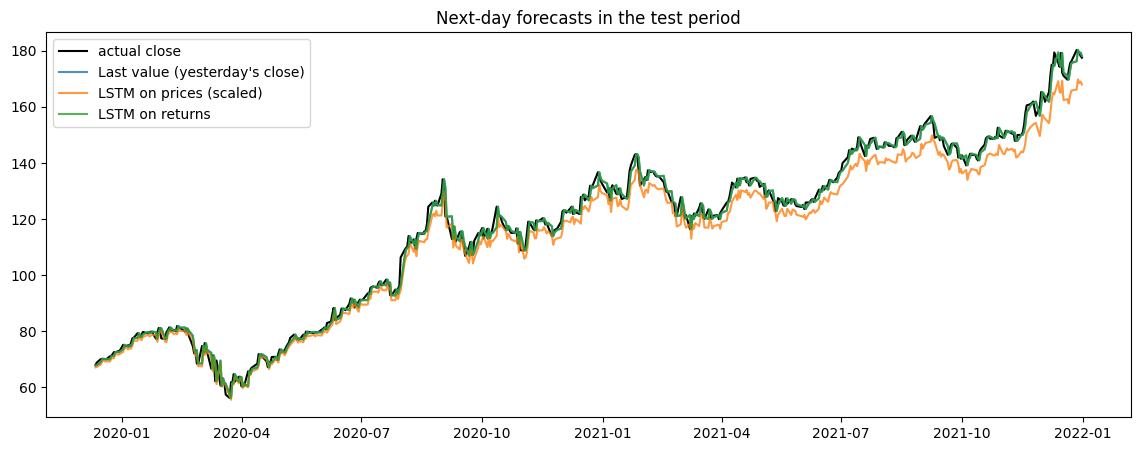

share of test days with a price rise: 54.2 %


In [9]:
plt.figure(figsize=(14, 5))
dates = data["Date"].iloc[test_days].values
plt.plot(dates, actual, color="black", label="actual close")
for name in ["Last value (yesterday's close)", "LSTM on prices (scaled)", "LSTM on returns"]:
    plt.plot(dates, comparison[name], label=name, alpha=0.8)
plt.legend(); plt.title("Next-day forecasts in the test period"); plt.show()

print("share of test days with a price rise:", round((actual > previous).mean() * 100, 1), "%")

The forecast of the next day's price is dominated by a simple fact: the best guess is yesterday's close. Repeating it gives a mean absolute error of 1.75 dollars (1.61% of the price) in the test period; the drift model is the same (the average daily change of the training years is only a few cents), and the mean of the last five days is worse (2.50) because it lags a price that keeps rising.

The LSTM trained on scaled prices is the worst model: its error is 4.09 dollars (3.32%), 2.3 times that of the naive forecast, and it underestimates the price by 3.76 dollars on average (the mean error, actual minus forecast, is positive). The model learned prices between 0 and 1 in a scaling made with the training years, in which the price never exceeded 44 dollars, while every price of the test period is above 56 dollars, and it cannot follow a price that is far above what it has seen; its direction is correct on only 45.6% of the days, less than a coin flip.

The LSTM trained on returns has no such problem, because a return does not depend on the level of the price. Its errors are identical to those of the naive forecast (MAE 1.75, RMSE 2.39), and it stopped after 10 epochs because it found nothing to learn: its predicted returns stay close to the average return, so its price forecast is almost yesterday's close. It gets the direction right on 55.2% of the days, while the price rose on 54.2% of the days: no real skill. Once a proper split and a baseline are used, the LSTM neither beats the naive forecast nor finds a signal in 60 days of past prices, in line with the behaviour of the stock price as a random walk seen in the ARIMA project.

## Conclusion

**Reference approach.** The reference "predicts" the close of the Apple stock from the open, the high, the low and the volume of the same day, with a random 80/20 split of the days and a two-layer LSTM (input of four time steps, batch size 1, 30 epochs, unscaled features). It reports the training loss and one typed example, and no error on test data.

**Findings.** The task is not a forecast: a plain linear regression on the same features reaches an R2 of 0.9999 and a mean error of 0.18 dollars (0.49%), because the high and the low of a day contain its close and the random split places the test days between the training days.

**Our approach.** The next day's close is predicted from the previous 60 days, with a split in time order (training until November 2017, validation until December 2019, and a test period of 518 days from 12 December 2019), scaling fitted on the training days, and early stopping on the validation loss:

| Forecast of the next day's close | MAE ($) | RMSE ($) | MAPE (%) | Direction correct (%) |
|---|---|---|---|---|
| Last value (yesterday's close) | 1.75 | 2.39 | 1.61 | not defined |
| Drift | 1.75 | 2.39 | 1.61 | 54.3 |
| Mean of the last 5 days | 2.50 | 3.32 | 2.25 | 51.7 |
| LSTM on scaled prices | 4.09 | 4.95 | 3.32 | 45.6 |
| LSTM on returns | 1.75 | 2.39 | 1.60 | 55.2 |

The LSTM on prices is 2.3 times worse than the naive forecast, because the price in the test period is far above the training range. The LSTM on returns is equal to the naive forecast: it does not find any signal in the past prices (direction correct on 55.2% of the days against 54.2% of days with a rise). With a proper test, a neural network gives no advantage over "tomorrow's price is today's price".

**Limitations.** One stock and one test period (a strong bull market) are used, so the results do not describe other stocks or periods. Only the past prices were used; volume, news, or the market were not tested. The network structure and the window of 60 days were not tuned, and each model was trained once with one seed. The test measures the error of the price, not the profit of a trading strategy, which would need the costs of trading and the direction accuracy of a much higher level than 55%. The prices are adjusted for the splits of 2014 and 2020.